## Phiên bản song song tối ưu hóa 3 được viết bằng shared memory + loop unrolling

### Lý thuyết
- `Loop unrolling` là kỹ thuật tối ưu bằng cách viết tường minh nhiều lần lặp trong vòng lặp, nhằm giảm overhead vòng lặp và tăng khả năng song song/ghi nhớ của bộ xử lý.
  
- Tăng băng thông bộ nhớ cache/shared memory nhờ truy cập liên tục, ít phân nhánh.


In [1]:
import os
import sys
from pathlib import Path

In [2]:
current_path = Path().resolve()
while current_path.name != "APP-project":
    if current_path.parent == current_path:
        raise FileNotFoundError("❌ Không tìm thấy thư mục gốc 'APP-project'")
    current_path = current_path.parent

os.chdir(current_path)
# print(f"📂 Project root set to: {current_path}")

In [3]:
sys.path.append('Src')
from Src import func as func

import numpy as np
import matplotlib.pyplot as plt

from numpy.lib.stride_tricks import as_strided

import random
import math
import time

from numba import cuda, float32

import warnings
warnings.filterwarnings('ignore')

### Class Conv2D

#### Bổ trợ

In [4]:
@cuda.jit
def mul_mat_kernel_shared_fused_unrolled(A, B, C):
    TILE_SIZE = 32
    sA = cuda.shared.array((TILE_SIZE, TILE_SIZE), dtype=float32)
    sB = cuda.shared.array((TILE_SIZE, TILE_SIZE), dtype=float32)

    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y
    row = cuda.blockIdx.x * TILE_SIZE + ty
    col = cuda.blockIdx.y * TILE_SIZE + tx

    acc = 0.0
    tiles = (A.shape[1] + TILE_SIZE - 1) // TILE_SIZE
    for m in range(tiles):
        # Load A tile
        if row < A.shape[0] and m * TILE_SIZE + tx < A.shape[1]:
            sA[ty, tx] = A[row, m * TILE_SIZE + tx]
        else:
            sA[ty, tx] = 0.0

        # Load B tile
        if m * TILE_SIZE + ty < B.shape[0] and col < B.shape[1]:
            sB[ty, tx] = B[m * TILE_SIZE + ty, col]
        else:
            sB[ty, tx] = 0.0

        cuda.syncthreads()

        # Unrolled loop over TILE_SIZE
        for k in range(0, TILE_SIZE, 4):
            acc += sA[ty, k]     * sB[k, tx]
            acc += sA[ty, k + 1] * sB[k + 1, tx]
            acc += sA[ty, k + 2] * sB[k + 2, tx]
            acc += sA[ty, k + 3] * sB[k + 3, tx]

        cuda.syncthreads()

    if row < C.shape[0] and col < C.shape[1]:
        C[row, col] = acc

@cuda.jit
def sum_axis0_kernel(arr, out):
    col = cuda.grid(1)
    if col < arr.shape[1]:
        total = 0.0
        for i in range(arr.shape[0]):
            total += arr[i, col]
        out[col] = total

@cuda.jit
def im2col_kernel(input_padded, cols, H, W, C, K, S, out_h, out_w):
    idx = cuda.grid(1)
    total = out_h * out_w
    if idx < total:
        i = idx // out_w
        j = idx % out_w
        for ki in range(K):
            for kj in range(K):
                for c in range(C):
                    row = i * S + ki
                    col = j * S + kj
                    val = input_padded[row, col, c]
                    cols[idx, c * K * K + ki * K + kj] = val

@cuda.jit
def col2im_kernel(dcols, grad_input_padded, H, W, C, K, S, out_h, out_w):
    idx = cuda.grid(1)
    total = out_h * out_w
    if idx < total:
        i = idx // out_w
        j = idx % out_w
        for ki in range(K):
            for kj in range(K):
                for c in range(C):
                    row = i * S + ki
                    col = j * S + kj
                    cuda.atomic.add(grad_input_padded, (row, col, c),
                                    dcols[idx, c * K * K + ki * K + kj])

def dot_cuda_shared(A, B):
    A = np.ascontiguousarray(A)
    B = np.ascontiguousarray(B)
    M, K = A.shape
    K2, N = B.shape
    assert K == K2
    C = np.zeros((M, N), dtype=np.float32)

    d_A = cuda.to_device(A)
    d_B = cuda.to_device(B)
    d_C = cuda.device_array((M, N), dtype=np.float32)

    threads = (32, 32)
    blocks = ((M + threads[0] - 1) // threads[0], (N + threads[1] - 1) // threads[1])
    mul_mat_kernel_shared_fused_unrolled[blocks, threads](d_A, d_B, d_C)
    return d_C.copy_to_host()

def sum_axis0_cuda(arr):
    arr = np.ascontiguousarray(arr)
    N = arr.shape[1]
    d_arr = cuda.to_device(arr)
    d_out = cuda.device_array(N, dtype=np.float32)
    threads = 256
    blocks = (N + threads - 1) // threads
    sum_axis0_kernel[blocks, threads](d_arr, d_out)
    return d_out.copy_to_host()

def im2col_cuda(x_padded, kernel_size, stride):
    H, W, C = x_padded.shape
    K = kernel_size
    S = stride
    out_h = (H - K) // S + 1
    out_w = (W - K) // S + 1
    cols = np.zeros((out_h * out_w, K * K * C), dtype=np.float32)

    d_input = cuda.to_device(x_padded)
    d_cols = cuda.to_device(cols)

    threads = 256
    blocks = (out_h * out_w + threads - 1) // threads
    im2col_kernel[blocks, threads](d_input, d_cols, H, W, C, K, S, out_h, out_w)
    return d_cols.copy_to_host(), out_h, out_w

def col2im_cuda(dcols, input_shape, kernel_size, stride, padding):
    H, W, C = input_shape
    H_pad, W_pad = H + 2 * padding, W + 2 * padding
    K = kernel_size
    S = stride
    out_h = (H_pad - K) // S + 1
    out_w = (W_pad - K) // S + 1

    grad_input_padded = np.zeros((H_pad, W_pad, C), dtype=np.float32)
    d_dcols = cuda.to_device(dcols)
    d_grad_input = cuda.to_device(grad_input_padded)

    threads = 256
    blocks = (out_h * out_w + threads - 1) // threads
    col2im_kernel[blocks, threads](d_dcols, d_grad_input, H_pad, W_pad, C, K, S, out_h, out_w)
    grad_input_padded = d_grad_input.copy_to_host()
    if padding > 0:
        return grad_input_padded[padding:-padding, padding:-padding, :]
    return grad_input_padded

#### Class 

In [5]:
class Conv2D_CUDA:
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=0, stride=1):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.padding = padding
        self.stride = stride

        limit = 0.1
        self.kernels = np.random.uniform(
            -limit, limit,
            (out_channels, kernel_size * kernel_size * in_channels)
        ).astype(np.float32)
        self.biases = np.random.uniform(-limit, limit, out_channels).astype(np.float32)

        self.v_kernels = np.zeros_like(self.kernels)
        self.v_biases = np.zeros_like(self.biases)

    def forward(self, input_data):
        self.input_data = input_data
        self.input_padded = np.pad(
            input_data,
            ((self.padding, self.padding), (self.padding, self.padding), (0, 0)),
            mode='constant'
        )

        self.cols, self.out_h, self.out_w = im2col_cuda(
            self.input_padded, self.kernel_size, self.stride
        )

        self.cols = np.ascontiguousarray(self.cols, dtype=np.float32)
        self.kernels = np.ascontiguousarray(self.kernels, dtype=np.float32)

        out = dot_cuda_shared(self.cols, self.kernels.T)
        out += self.biases
        return out.reshape(self.out_h, self.out_w, self.out_channels)

    def backward(self, grad_output):
        dout_flat = grad_output.reshape(-1, self.out_channels).astype(np.float32)

        self.grad_kernels = dot_cuda_shared(dout_flat.T, self.cols)
        self.grad_biases = sum_axis0_cuda(dout_flat)
        dcols = dot_cuda_shared(dout_flat, self.kernels)

        grad_input = col2im_cuda(
            dcols, self.input_data.shape, self.kernel_size, self.stride, self.padding
        )
        return grad_input

    def step(self, lr, momentum=0.9):
        self.v_kernels = momentum * self.v_kernels - lr * self.grad_kernels
        self.v_biases = momentum * self.v_biases - lr * self.grad_biases
        self.kernels += self.v_kernels
        self.biases += self.v_biases

#### Test

In [6]:
X_train, y_train_onehot, X_test, y_test_onehot = func.preprocess_cifar10_data()

# in shape của dữ liệu
print(f"X_train shape: {X_train.shape}")
print(f"y_train_onehot shape: {y_train_onehot.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test_onehot shape: {y_test_onehot.shape}")

X_train shape: (50000, 32, 32, 3)
y_train_onehot shape: (50000, 10)
X_test shape: (10000, 32, 32, 3)
y_test_onehot shape: (10000, 10)


In [7]:
# Test Conv2D_CUDA với 1 ảnh từ CIFAR-10
# Giả lập quy trình forward -> backward -> step

# Lấy 1 sample từ CIFAR-10
x = X_train[0]                    # (32, 32, 3)
y = y_train_onehot[0]            # (10,)

# Khởi tạo Conv2D_CUDA layer
conv = Conv2D_CUDA(in_channels=3, out_channels=8, kernel_size=3, padding=1, stride=1)

# ============ FORWARD ============
out = conv.forward(x)            # (32, 32, 8)
print("✅ Forward output shape:", out.shape)
print(f"📊 Output stats - mean: {out.mean():.6f}, std: {out.std():.6f}, min: {out.min():.6f}, max: {out.max():.6f}")

# ============ FAKE LOSS GRADIENT ============
# Tạo grad_output giả lập từ loss, shape khớp output
grad_output = np.random.randn(*out.shape).astype(np.float32)

# ============ BACKWARD ============
grad_input = conv.backward(grad_output)  # (32, 32, 3)
print("🔁 Backward grad_input shape:", grad_input.shape)
print(f"📉 Grad stats - mean: {grad_input.mean():.6f}, std: {grad_input.std():.6f}")

# ============ STEP ============
conv.step(lr=0.001, momentum=0.9)
print("✅ Step hoàn tất. Trọng số đã cập nhật.")


✅ Forward output shape: (32, 32, 8)
📊 Output stats - mean: -0.036728, std: 0.082752, min: -0.387272, max: 0.297212
🔁 Backward grad_input shape: (32, 32, 3)
📉 Grad stats - mean: 0.009665, std: 0.477245
✅ Step hoàn tất. Trọng số đã cập nhật.


### **Class Relu**

#### Class 

In [8]:
# CUDA kernel for ReLU forward: y = max(0, x)
@cuda.jit
def relu_forward_kernel(x, y):
    idx = cuda.grid(1)
    if idx < x.size:
        y[idx] = max(0.0, x[idx])

# CUDA kernel for ReLU backward: dy = grad_output * (x > 0)
@cuda.jit
def relu_backward_kernel(grad_output, x, grad_input):
    idx = cuda.grid(1)
    if idx < grad_output.size:
        grad_input[idx] = grad_output[idx] if x[idx] > 0 else 0.0

# ReLU_CUDA class
class ReLU_CUDA:
    def forward(self, x):
        self.input_shape = x.shape
        x_flat = x.flatten().astype(np.float32)
        y_flat = np.zeros_like(x_flat)

        d_x = cuda.to_device(x_flat)
        d_y = cuda.device_array_like(y_flat)

        threads = 256
        blocks = (x_flat.size + threads - 1) // threads
        relu_forward_kernel[blocks, threads](d_x, d_y)

        self.input_flat = x_flat  # Save for backward
        self.output_flat = d_y.copy_to_host()
        return self.output_flat.reshape(self.input_shape)

    def backward(self, grad_output):
        grad_output_flat = grad_output.flatten().astype(np.float32)
        grad_input_flat = np.zeros_like(grad_output_flat)

        d_grad_output = cuda.to_device(grad_output_flat)
        d_input = cuda.to_device(self.input_flat)
        d_grad_input = cuda.device_array_like(grad_input_flat)

        threads = 256
        blocks = (grad_output_flat.size + threads - 1) // threads
        relu_backward_kernel[blocks, threads](d_grad_output, d_input, d_grad_input)

        return d_grad_input.copy_to_host().reshape(self.input_shape)

#### Test

In [9]:
# Khởi tạo ReLU
relu = ReLU_CUDA()

# FORWARD từ output conv trước đó
out_relu = relu.forward(out)
print("🔋 ReLU Output - shape:", out_relu.shape)
print(f"📊 ReLU stats - mean: {out_relu.mean():.6f}, std: {out_relu.std():.6f}, zeros: {np.sum(out_relu == 0)} / {out_relu.size}")

# BACKWARD với grad giả lập
grad_output = np.random.randn(*out.shape).astype(np.float32)
grad_relu = relu.backward(grad_output)
print("🔁 ReLU Backward - shape:", grad_relu.shape)
print(f"📉 Grad stats - mean: {grad_relu.mean():.6f}, std: {grad_relu.std():.6f}")

🔋 ReLU Output - shape: (32, 32, 8)
📊 ReLU stats - mean: 0.018544, std: 0.032636, zeros: 5215 / 8192
🔁 ReLU Backward - shape: (32, 32, 8)
📉 Grad stats - mean: 0.012209, std: 0.597181


### **Class MaxPool2D**

In [10]:
# 1. MaxPool2D - FORWARD kernel
@cuda.jit
def maxpool2d_forward_kernel(x, out, max_indices, k, s, H, W, C, out_h, out_w):
    idx = cuda.grid(1)
    total = out_h * out_w * C
    if idx < total:
        ow = idx % out_w
        oh = (idx // out_w) % out_h
        c = idx // (out_h * out_w)

        max_val = -1e20
        max_idx = 0
        for i in range(k):
            for j in range(k):
                h = oh * s + i
                w = ow * s + j
                val = x[h, w, c]
                if val > max_val:
                    max_val = val
                    max_idx = i * k + j
        out[oh, ow, c] = max_val
        max_indices[oh, ow, c] = max_idx

# 2. MaxPool2D - BACKWARD kernel
@cuda.jit
def maxpool2d_backward_kernel(d_out, max_indices, d_input, k, s, out_h, out_w, H, W, C):
    idx = cuda.grid(1)
    total = out_h * out_w * C
    if idx < total:
        ow = idx % out_w
        oh = (idx // out_w) % out_h
        c = idx // (out_h * out_w)

        max_idx = max_indices[oh, ow, c]
        u = max_idx // k
        v = max_idx % k

        h = oh * s + u
        w = ow * s + v

        cuda.atomic.add(d_input, (h, w, c), d_out[oh, ow, c])

# 3. MaxPool2D_CUDA class
class MaxPool2D_CUDA:
    def __init__(self, kernel_size=2, stride=2):
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x):
        self.input = x
        H, W, C = x.shape
        k = self.kernel_size
        s = self.stride

        out_h = (H - k) // s + 1
        out_w = (W - k) // s + 1

        out = np.zeros((out_h, out_w, C), dtype=np.float32)
        max_indices = np.zeros_like(out, dtype=np.int32)

        d_x = cuda.to_device(x)
        d_out = cuda.to_device(out)
        d_max_indices = cuda.to_device(max_indices)

        threads = 256
        blocks = (out_h * out_w * C + threads - 1) // threads
        maxpool2d_forward_kernel[blocks, threads](d_x, d_out, d_max_indices, k, s, H, W, C, out_h, out_w)

        self.max_indices = d_max_indices.copy_to_host()
        self.out_shape = out.shape
        return d_out.copy_to_host()

    def backward(self, d_out):
        H, W, C = self.input.shape
        k = self.kernel_size
        s = self.stride
        out_h, out_w, _ = self.out_shape

        d_input = np.zeros_like(self.input, dtype=np.float32)

        d_dout = cuda.to_device(np.ascontiguousarray(d_out))
        d_max_indices = cuda.to_device(self.max_indices)
        d_dinput = cuda.to_device(d_input)

        threads = 256
        blocks = (out_h * out_w * C + threads - 1) // threads
        maxpool2d_backward_kernel[blocks, threads](d_dout, d_max_indices, d_dinput, k, s, out_h, out_w, H, W, C)

        return d_dinput.copy_to_host()

#### Test

In [11]:
pool = MaxPool2D_CUDA(kernel_size=2, stride=2)

out_pool = pool.forward(out_relu)
print("✅ MaxPool output shape:", out_pool.shape)
print("🧊 Zero count:", np.sum(out_pool == 0))

# Backward với grad giả
grad_fake = np.random.randn(*out_pool.shape).astype(np.float32)
grad_pool = pool.backward(grad_fake)
print("🔁 Backward shape:", grad_pool.shape)
print(f"📉 Grad stats: mean={grad_pool.mean():.6f}, std={grad_pool.std():.6f}")

✅ MaxPool output shape: (16, 16, 8)
🧊 Zero count: 1162
🔁 Backward shape: (32, 32, 8)
📉 Grad stats: mean=0.004157, std=0.501026


### **Conv Block**

In [12]:
class ConvBlock_CUDA:
    def __init__(self, in_channels, out_channels, num_convs=2, padding=0, stride=1):
        self.convs = []
        self.relus = []

        for _ in range(num_convs):
            conv = Conv2D_CUDA(in_channels, out_channels, kernel_size=3, padding=padding, stride=stride)
            relu = ReLU_CUDA()
            self.convs.append(conv)
            self.relus.append(relu)
            in_channels = out_channels  # chuẩn bị cho conv tiếp theo

        self.pool = MaxPool2D_CUDA(kernel_size=2, stride=2)

    def forward(self, input):
        x = input
        for conv, relu in zip(self.convs, self.relus):
            x = conv.forward(x)
            x = relu.forward(x)
        x = self.pool.forward(x)
        return x

    def backward(self, d_out):
        d_out = self.pool.backward(d_out)
        for conv, relu in zip(reversed(self.convs), reversed(self.relus)):
            d_out = relu.backward(d_out)
            d_out = conv.backward(d_out)
        return d_out

    def step(self, learning_rate, momentum=0.9):
        for conv in self.convs:
            conv.step(learning_rate, momentum)

#### Test

In [13]:
# ======== LẤY MẪU DỮ LIỆU ========
x = X_train[0]                    # (32, 32, 3)
y = y_train_onehot[0]            # (10,)

# ======== KHỞI TẠO BLOCK ========
block = ConvBlock_CUDA(in_channels=3, out_channels=8, num_convs=2, padding=1, stride=1)

# ======== FORWARD ========
out = block.forward(x)
print("✅ ConvBlock forward output shape:", out.shape)
print(f"📊 mean={out.mean():.6f}, std={out.std():.6f}, min={out.min():.6f}, max={out.max():.6f}")

# ======== GIẢ GRADIENT (từ FC hoặc loss) ========
grad_fake = np.random.randn(*out.shape).astype(np.float32)

# ======== BACKWARD ========
grad_input = block.backward(grad_fake)
print("🔁 ConvBlock backward grad_input shape:", grad_input.shape)
print(f"📉 mean={grad_input.mean():.6f}, std={grad_input.std():.6f}")

# ======== STEP (update trọng số) ========
block.step(learning_rate=0.001, momentum=0.9)
print("✅ Step hoàn tất, các Conv2D bên trong đã được cập nhật.")

✅ ConvBlock forward output shape: (16, 16, 8)
📊 mean=0.042512, std=0.036462, min=0.000000, max=0.146758
🔁 ConvBlock backward grad_input shape: (32, 32, 3)
📉 mean=0.001093, std=0.075953
✅ Step hoàn tất, các Conv2D bên trong đã được cập nhật.


### **Flatten**

In [14]:
# Flatten forward kernel: flatten 3D -> 1D
@cuda.jit
def flatten_forward_kernel(x, y):
    idx = cuda.grid(1)
    if idx < x.size:
        y[idx] = x[idx]

# Flatten backward kernel: reshape 1D -> 3D
@cuda.jit
def flatten_backward_kernel(grad_output, grad_input):
    idx = cuda.grid(1)
    if idx < grad_output.size:
        grad_input[idx] = grad_output[idx]

# Flatten_CUDA class
class Flatten_CUDA:
    def forward(self, input):
        self.input_shape = input.shape  # (H, W, C)
        x = input.flatten().astype(np.float32)
        y = np.empty_like(x)

        d_x = cuda.to_device(x)
        d_y = cuda.device_array_like(x)

        threads = 256
        blocks = (x.size + threads - 1) // threads
        flatten_forward_kernel[blocks, threads](d_x, d_y)

        return d_y.copy_to_host()

    def backward(self, grad_output):
        grad_output_flat = grad_output.flatten().astype(np.float32)
        grad_input_flat = np.empty_like(grad_output_flat)

        d_out = cuda.to_device(grad_output_flat)
        d_in = cuda.device_array_like(grad_input_flat)

        threads = 256
        blocks = (grad_output_flat.size + threads - 1) // threads
        flatten_backward_kernel[blocks, threads](d_out, d_in)

        return d_in.copy_to_host().reshape(self.input_shape)

### **Fully Connected Layer**

In [15]:
class FullyConnected_CUDA:
    def __init__(self, in_dim, out_dim):
        limit = 0.01
        self.W = np.random.uniform(-limit, limit, (in_dim, out_dim)).astype(np.float32)
        self.b = np.random.uniform(-limit, limit, out_dim).astype(np.float32)

        self.v_W = np.zeros_like(self.W)
        self.v_b = np.zeros_like(self.b)

    def forward(self, x):
        self.input = x.astype(np.float32)
        self.input_flat = np.ascontiguousarray(self.input).reshape(1, -1)  # (1, in_dim)
        W = np.ascontiguousarray(self.W)                                   # (in_dim, out_dim)
        out = dot_cuda_shared(self.input_flat, W)                                 # (1, out_dim)
        return (out[0] + self.b)                                           # (out_dim,)

    def backward(self, grad_output):
        grad_output = grad_output.astype(np.float32).reshape(1, -1)  # (1, out_dim)

        self.grad_W = dot_cuda_shared(self.input_flat.T, grad_output)       # (in_dim, out_dim)
        self.grad_b = grad_output[0]                                 # (out_dim,)
        grad_input = dot_cuda_shared(grad_output, self.W.T)                 # (1, in_dim)

        return grad_input[0]                                         # (in_dim,)

    def step(self, learning_rate, momentum=0.9):
        self.v_W = momentum * self.v_W - learning_rate * self.grad_W
        self.v_b = momentum * self.v_b - learning_rate * self.grad_b
        self.W += self.v_W
        self.b += self.v_b

        # print("🧠 [FC_CUDA] W mean:", self.W.mean(), "std:", self.W.std())

#### Test

In [16]:
# Dữ liệu giả lập output sau ConvBlock
x = np.random.randn(16, 16, 8).astype(np.float32)

flatten = Flatten_CUDA()
x_flat = flatten.forward(x)
print("✅ Flatten shape:", x_flat.shape)

fc = FullyConnected_CUDA(in_dim=x_flat.shape[0], out_dim=10)
out = fc.forward(x_flat)
print("✅ FC output:", out.shape)

grad_output = np.random.randn(10).astype(np.float32)
grad_fc = fc.backward(grad_output)
grad_input = flatten.backward(grad_fc)

print("🔁 Backward shapes:", grad_fc.shape, grad_input.shape)
fc.step(learning_rate=0.001, momentum=0.9)

✅ Flatten shape: (2048,)
✅ FC output: (10,)
🔁 Backward shapes: (2048,) (16, 16, 8)


### **Relu cho Vector**

In [17]:
# CUDA kernels for ReLUVector
@cuda.jit
def relu_vector_forward_kernel(x, y):
    idx = cuda.grid(1)
    if idx < x.size:
        y[idx] = max(0.0, x[idx])

@cuda.jit
def relu_vector_backward_kernel(grad_output, x, grad_input):
    idx = cuda.grid(1)
    if idx < grad_output.size:
        grad_input[idx] = grad_output[idx] if x[idx] > 0 else 0.0

# ReLUVector_CUDA class
class ReLUVector_CUDA:
    def forward(self, x):
        self.input = x.astype(np.float32)
        self.output = np.empty_like(self.input)

        d_x = cuda.to_device(self.input)
        d_y = cuda.device_array_like(self.input)

        threads = 256
        blocks = (self.input.size + threads - 1) // threads
        relu_vector_forward_kernel[blocks, threads](d_x, d_y)

        self.output = d_y.copy_to_host()
        return self.output

    def backward(self, grad_output):
        grad_output = grad_output.astype(np.float32)
        grad_input = np.empty_like(grad_output)

        d_grad_output = cuda.to_device(grad_output)
        d_input = cuda.to_device(self.input)
        d_grad_input = cuda.device_array_like(grad_output)

        threads = 256
        blocks = (grad_output.size + threads - 1) // threads
        relu_vector_backward_kernel[blocks, threads](d_grad_output, d_input, d_grad_input)

        return d_grad_input.copy_to_host()

### **Softmax + CrossEntropyLoss**

In [18]:
class Softmax_CUDA:
    def forward(self, x):
        self.input = x.astype(np.float32)
        x_stable = self.input - np.max(self.input)
        exps = np.exp(x_stable)
        self.output = exps / np.sum(exps)
        return self.output

class CrossEntropyLoss_CUDA:
    def forward(self, pred_probs, target_onehot):
        self.pred_probs = pred_probs.astype(np.float32)
        self.target_onehot = target_onehot.astype(np.float32)
        return -np.sum(self.target_onehot * np.log(self.pred_probs + 1e-12))

    def backward(self):
        return self.pred_probs - self.target_onehot

### **Class Cấu Trúc**

In [19]:
class SimpleCNN_CUDA:
    def __init__(self):
        self.block1 = ConvBlock_CUDA(3, 64, num_convs=2, padding=1)
        self.block2 = ConvBlock_CUDA(64, 128, num_convs=2, padding=1)
        self.block3 = ConvBlock_CUDA(128, 256, num_convs=2, padding=1)

        self.flatten = Flatten_CUDA()
        self.fc1 = FullyConnected_CUDA(256 * 4 * 4, 512)
        self.relu_fc1 = ReLUVector_CUDA()
        self.fc2 = FullyConnected_CUDA(512, 10)
        self.softmax = Softmax_CUDA()

### **Train**

#### Hàm train

In [20]:
def train_cuda(model, train_data, train_labels, epochs=1, learning_rate=0.001,
                     mb_size=32, momentum=0.9, lr_decay_factor=0.5,
                     log_filename="training_log_cuda.csv", detail_log_filename="details_log_cuda.csv"):

    np.random.seed(0)
    cross_entropy = CrossEntropyLoss_CUDA()
    n_samples = train_data.shape[0]
    indices = np.arange(n_samples)

    best_train_acc = 0
    plateau_count = 0
    patience = 2

    for epoch in range(epochs):
        start_epoch = time.time()
        total_loss = 0.0
        correct = 0

        conv2d_time = relu_time = maxpool_time = flatten_time = fc_time = softmax_time = 0.0

        np.random.shuffle(indices)
        train_data_shuffled = train_data[indices]
        train_labels_shuffled = train_labels[indices]

        full_batch_count = n_samples // mb_size
        for i in range(full_batch_count):
            start = i * mb_size
            end = start + mb_size
            X_batch = train_data_shuffled[start:end]
            y_batch = train_labels_shuffled[start:end]

            for x_idx, (x, target) in enumerate(zip(X_batch, y_batch)):
                print(f"\n📌 Sample {i * mb_size + x_idx}")
                ## ====== FORWARD ======
                out = x
                for conv, relu in zip(model.block1.convs, model.block1.relus):
                    t0 = time.time(); out = conv.forward(out); t1 = time.time(); conv2d_time += t1 - t0
                    t0 = time.time(); out = relu.forward(out); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); out = model.block1.pool.forward(out); t1 = time.time(); maxpool_time += t1 - t0

                for conv, relu in zip(model.block2.convs, model.block2.relus):
                    t0 = time.time(); out = conv.forward(out); t1 = time.time(); conv2d_time += t1 - t0
                    t0 = time.time(); out = relu.forward(out); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); out = model.block2.pool.forward(out); t1 = time.time(); maxpool_time += t1 - t0

                for conv, relu in zip(model.block3.convs, model.block3.relus):
                    t0 = time.time(); out = conv.forward(out); t1 = time.time(); conv2d_time += t1 - t0
                    t0 = time.time(); out = relu.forward(out); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); out = model.block3.pool.forward(out); t1 = time.time(); maxpool_time += t1 - t0

                t0 = time.time(); out = model.flatten.forward(out); t1 = time.time(); flatten_time += t1 - t0
                t0 = time.time(); out = model.fc1.forward(out); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); out = model.relu_fc1.forward(out); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); out = model.fc2.forward(out); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); pred_probs = model.softmax.forward(out); t1 = time.time(); softmax_time += t1 - t0

                loss = cross_entropy.forward(pred_probs, target)
                total_loss += loss
                pred_idx = np.argmax(pred_probs)
                true_idx = np.argmax(target)

                if pred_idx == true_idx:
                    correct += 1
                    print(f"✔ Predict: {pred_idx}, True: {true_idx}")
                else:
                    print(f"❌ Predict: {pred_idx}, True: {true_idx}")

                ## ====== BACKWARD ======
                t0 = time.time(); grad = cross_entropy.backward(); t1 = time.time(); softmax_time += t1 - t0
                t0 = time.time(); grad = model.fc2.backward(grad); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); grad = model.relu_fc1.backward(grad); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); grad = model.fc1.backward(grad); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); grad = model.flatten.backward(grad); t1 = time.time(); flatten_time += t1 - t0

                t0 = time.time(); grad = model.block3.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
                for conv, relu in zip(reversed(model.block3.convs), reversed(model.block3.relus)):
                    t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                    t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

                t0 = time.time(); grad = model.block2.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
                for conv, relu in zip(reversed(model.block2.convs), reversed(model.block2.relus)):
                    t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                    t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

                t0 = time.time(); grad = model.block1.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
                for conv, relu in zip(reversed(model.block1.convs), reversed(model.block1.relus)):
                    t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                    t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

                ## ====== UPDATE ======
                model.fc2.step(learning_rate, momentum)
                model.fc1.step(learning_rate, momentum)
                model.block3.step(learning_rate, momentum)
                model.block2.step(learning_rate, momentum)
                model.block1.step(learning_rate, momentum)

        end_epoch = time.time()
        epoch_time = end_epoch - start_epoch
        accuracy = correct / (full_batch_count * mb_size)

        func.log_training_details(epoch, epochs, epoch_time, n_samples, total_loss / (full_batch_count * mb_size), accuracy, log_filename)
        func.log_details(f"Epoch_{epoch+1}", mb_size, conv2d_time, relu_time, maxpool_time, flatten_time, fc_time, softmax_time, detail_log_filename)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/(full_batch_count * mb_size):.4f} - Acc: {accuracy:.4f} - Time: {epoch_time:.2f}s")
        print(f"    Conv2D: {conv2d_time:.2f}s | ReLU: {relu_time:.2f}s | MaxPool: {maxpool_time:.2f}s | Flatten: {flatten_time:.2f}s | FC: {fc_time:.2f}s | Softmax: {softmax_time:.2f}s\n")

        # Learning rate scheduler
        if epoch == 0:
            best_train_acc = accuracy
            plateau_count = 0
        else:
            if accuracy > best_train_acc:
                best_train_acc = accuracy
                plateau_count = 0
            else:
                plateau_count += 1
                if plateau_count >= patience:
                    learning_rate *= lr_decay_factor
                    plateau_count = 0
                    print(f"⚠️  ReduceLROnPlateau: Learning rate reduced to {learning_rate:.6f}")

#### 10 ảnh, 1 epoch

In [31]:
model = SimpleCNN_CUDA()
train_cuda(
    model,
    X_train[:10],  # train thử 10 mẫu đầua
    y_train_onehot[:10],
    epochs=1,        # train thử 1 epoch
    learning_rate=0.001,
    mb_size=2,
    momentum=0.9,
    lr_decay_factor=0.5,
    log_filename="Data/log/training_log_cuda_ver4_op3_10.csv",
    detail_log_filename="Data/log/details_log_cuda_ver4_op3_10.csv"
)


📌 Sample 0
❌ Predict: 1, True: 9

📌 Sample 1
❌ Predict: 9, True: 8

📌 Sample 2
❌ Predict: 9, True: 1

📌 Sample 3
❌ Predict: 9, True: 3

📌 Sample 4
✔ Predict: 9, True: 9

📌 Sample 5
❌ Predict: 9, True: 2

📌 Sample 6
❌ Predict: 9, True: 7

📌 Sample 7
❌ Predict: 9, True: 4

📌 Sample 8
❌ Predict: 9, True: 6

📌 Sample 9
❌ Predict: 9, True: 1
Epoch 1/1 - Loss: 2.3207 - Acc: 0.1000 - Time: 2.14s
    Conv2D: 1.15s | ReLU: 0.15s | MaxPool: 0.09s | Flatten: 0.01s | FC: 0.52s | Softmax: 0.00s



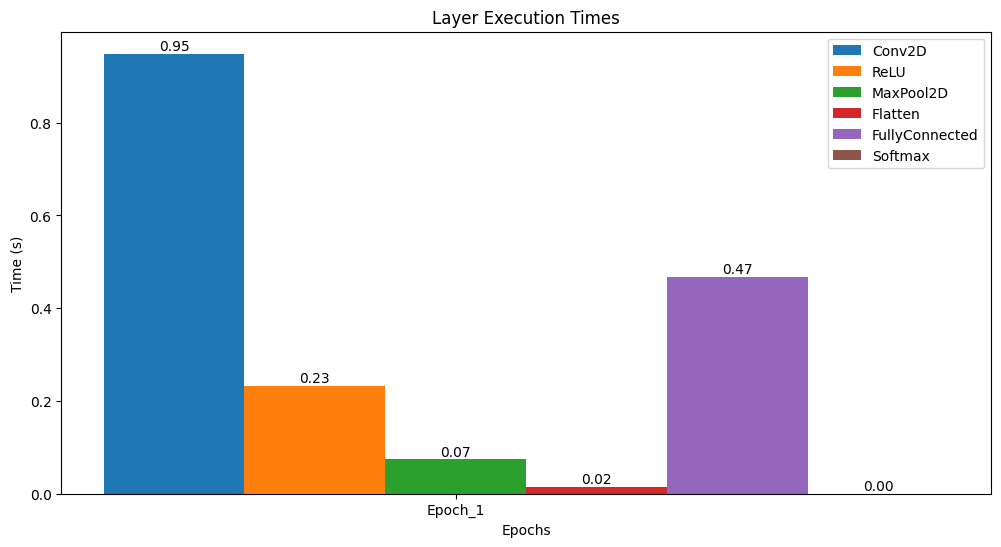

In [22]:
func.plot_details("Data/log/details_log_cuda_ver4_op3_10.csv")

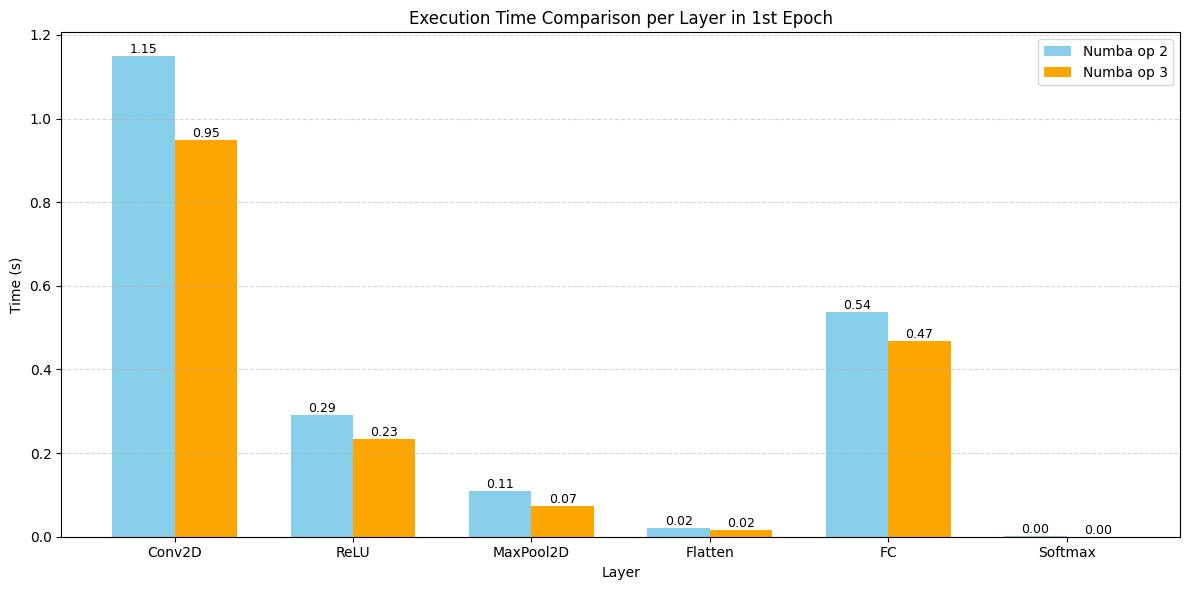

In [23]:
func.plot_compare_details_customized(
    "Data/log/details_log_cuda_ver4_op2_10.csv",
    "Data/log/details_log_cuda_ver4_op3_10.csv",
    "Numba op 2",
    "Numba op 3"
)

#### 50000 ảnh, 1 epoch

In [24]:
model_2 = SimpleCNN_CUDA()
train_cuda(
    model_2,
    X_train,
    y_train_onehot,
    epochs=1,        # train thử 1 epoch
    learning_rate=0.001,
    momentum=0.9,
    lr_decay_factor=0.5,
    mb_size=64,
    log_filename="Data/log/training_log_cuda_ver4_50000_op3_1.csv",
    detail_log_filename="Data/log/details_log_cuda_ver4_50000_op3_1.csv"
)


📌 Sample 0
❌ Predict: 9, True: 7

📌 Sample 1
❌ Predict: 3, True: 5

📌 Sample 2
✔ Predict: 5, True: 5

📌 Sample 3
❌ Predict: 5, True: 6

📌 Sample 4
✔ Predict: 5, True: 5

📌 Sample 5
❌ Predict: 5, True: 4

📌 Sample 6
❌ Predict: 5, True: 3

📌 Sample 7
❌ Predict: 5, True: 0

📌 Sample 8
❌ Predict: 5, True: 7

📌 Sample 9
❌ Predict: 5, True: 2

📌 Sample 10
✔ Predict: 5, True: 5

📌 Sample 11
❌ Predict: 5, True: 0

📌 Sample 12
❌ Predict: 5, True: 3

📌 Sample 13
❌ Predict: 5, True: 4

📌 Sample 14
❌ Predict: 5, True: 9

📌 Sample 15
❌ Predict: 5, True: 2

📌 Sample 16
❌ Predict: 5, True: 4

📌 Sample 17
❌ Predict: 5, True: 7

📌 Sample 18
❌ Predict: 5, True: 7

📌 Sample 19
✔ Predict: 5, True: 5

📌 Sample 20
✔ Predict: 5, True: 5

📌 Sample 21
❌ Predict: 5, True: 4

📌 Sample 22
❌ Predict: 5, True: 1

📌 Sample 23
❌ Predict: 5, True: 9

📌 Sample 24
❌ Predict: 5, True: 3

📌 Sample 25
❌ Predict: 5, True: 9

📌 Sample 26
❌ Predict: 5, True: 6

📌 Sample 27
❌ Predict: 5, True: 2

📌 Sample 28
❌ Predict: 5, Tru

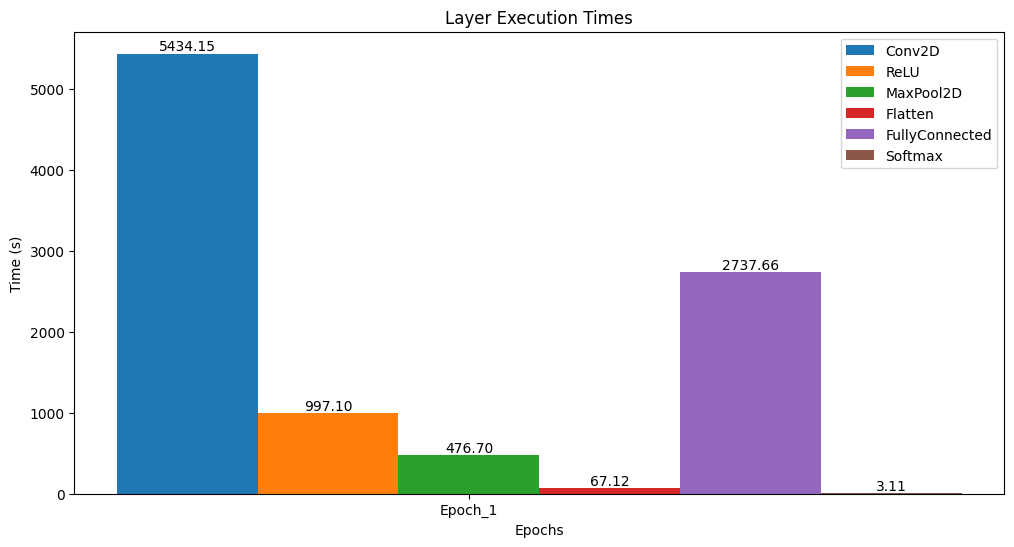

In [25]:
func.plot_details("Data/log/details_log_cuda_ver4_50000_op3_1.csv")

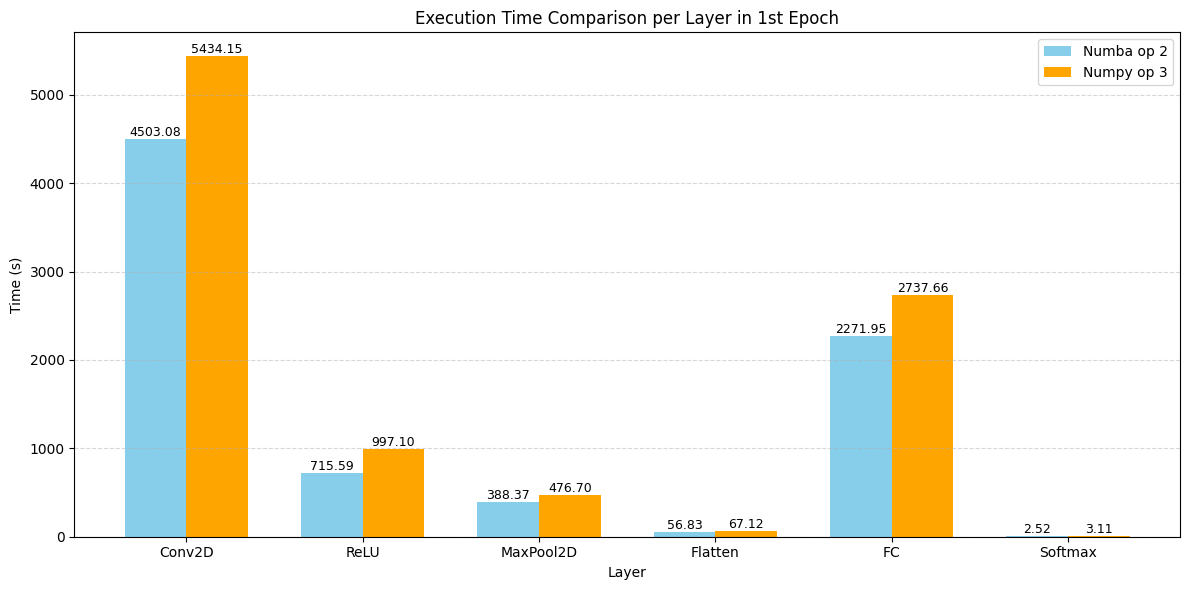

In [26]:
func.plot_compare_details_customized(
    "Data/log/details_log_cuda_ver4_50000_op2_1.csv",
    "Data/log/details_log_cuda_ver4_50000_op3_1.csv",
    "Numba op 2",
    "Numpy op 3"
)

In [27]:
# func.plot_timeline_from_log(
#     "Data/log/training_log_numpy_50000_10.csv",
#     columns = ["Accuracy"],
#     title = "Accuracy over epochs",
#     ylabel = "Accuracy",
# )

### Nhận xét chung
- Nhóm không biết vì sao khi đã tối ưu hóa với loop unrolling + shared thời gian chạy vẫn không giảm mà thậm chí còn tăng lên…

### Định hướng kế tiếp
Phiên bản song song tối ưu hóa 4 kết hợp từ tất cả phiên bản tối ưu hóa trên: stream + shared memory + loop unrolling 